In [1]:
# Cell 1 — Imports and config
import warnings
warnings.filterwarnings('ignore')

import torch
import cv2
import numpy as np
from PIL import Image
from pathlib import Path
from transformers import AutoModel, AutoProcessor
import pandas as pd
import json
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import os

DEVICE = 'cpu'
MODEL_ID = 'google/siglip2-base-patch16-224'
NUM_FRAMES = 8
MAX_PER_CLASS = 10
PROMPT_TEMPLATE = 'a video of {}'
UCF_ROOT = '../data/ucf101/UCF-101'
CLASSLIST = '../data/ucf101/ucfTrainTestlist/classInd.txt'
TESTLIST = '../data/ucf101/ucfTrainTestlist/testlist01.txt'
OUTPUT_DIR = '../outputs'

os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f'Device  : {DEVICE}')
print(f'Model   : {MODEL_ID}')
print(f'Frames  : {NUM_FRAMES} per video')
print(f'Videos  : {MAX_PER_CLASS} per class')

Device  : cpu
Model   : google/siglip2-base-patch16-224
Frames  : 8 per video
Videos  : 10 per class


In [2]:
# Cell 2 — Load model and encode class labels
print('Loading SigLIP 2 (~1.7GB, first run will download)...')
model = AutoModel.from_pretrained(MODEL_ID).eval()
processor = AutoProcessor.from_pretrained(MODEL_ID)
print('Model loaded')

classes = {}
with open(CLASSLIST) as f:
    for line in f:
        idx, name = line.strip().split()
        classes[int(idx)] = name.replace('_', ' ').lower()

label_list = [classes[k] for k in sorted(classes)]
prompts = [PROMPT_TEMPLATE.format(l) for l in label_list]

text_inputs = processor(
    text=prompts,
    padding='max_length',
    truncation=True,
    max_length=64,
    return_tensors='pt'
)

with torch.no_grad():
    text_output = model.get_text_features(**text_inputs)
    text_embs = text_output.pooler_output if hasattr(text_output, 'pooler_output') else text_output[0][:, 0, :]
    text_embs = text_embs / text_embs.norm(dim=-1, keepdim=True)

print(f'Encoded {len(label_list)} class labels')
print('Sample labels:', label_list[:5])

Loading SigLIP 2 (~1.7GB, first run will download)...


config.json:   0%|          | 0.00/253 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.50G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/394 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/34.4M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

Model loaded
Encoded 101 class labels
Sample labels: ['applyeyemakeup', 'applylipstick', 'archery', 'babycrawling', 'balancebeam']


In [3]:
# Cell 3 — Run benchmark
def load_test_videos(testlist, root, max_per_class):
    root = Path(root)
    videos, counts = [], {}
    with open(testlist) as f:
        for line in f:
            rel = line.strip()
            label = rel.split('/')[0].replace('_', ' ').lower()
            if counts.get(label, 0) >= max_per_class:
                continue
            full = root / rel
            if full.exists():
                videos.append({'path': str(full), 'label': label})
                counts[label] = counts.get(label, 0) + 1
    return videos


def extract_frames(path, n=8):
    cap = cv2.VideoCapture(path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total == 0:
        cap.release()
        return []
    frames = []
    for idx in np.linspace(0, total - 1, n, dtype=int):
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if ret:
            frames.append(Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)))
    cap.release()
    return frames


videos = load_test_videos(TESTLIST, UCF_ROOT, MAX_PER_CLASS)
print(f'Total videos to evaluate: {len(videos)}')

results = []
for video in tqdm(videos, desc='Evaluating'):
    frames = extract_frames(video['path'], NUM_FRAMES)
    if not frames:
        continue

    image_inputs = processor(images=frames, return_tensors='pt')

    with torch.no_grad():
        frame_output = model.get_image_features(**image_inputs)
        frame_embs = frame_output.pooler_output if hasattr(frame_output, 'pooler_output') else frame_output[0][:, 0, :]
        frame_embs = frame_embs / frame_embs.norm(dim=-1, keepdim=True)
        video_emb = frame_embs.mean(dim=0)
        video_emb = video_emb / video_emb.norm()

    logit_scale = model.logit_scale.exp()
    logit_bias = model.logit_bias
    logits = video_emb @ text_embs.T * logit_scale + logit_bias
    scores = torch.sigmoid(logits).detach().cpu().numpy()

    top5 = [label_list[i] for i in np.argsort(scores)[::-1][:5]]
    results.append({
        'video': Path(video['path']).name,
        'true_label': video['label'],
        'top1_pred': top5[0],
        'top5_preds': top5,
        'top1_correct': video['label'] == top5[0],
        'top5_correct': video['label'] in top5,
    })

df = pd.DataFrame(results)
df.to_csv(f'{OUTPUT_DIR}/results_siglip2.csv', index=False)
print(f'Saved results_siglip2.csv — {len(df)} videos evaluated')

Total videos to evaluate: 1010


Evaluating:   0%|          | 0/1010 [00:00<?, ?it/s]

Saved results_siglip2.csv — 1010 videos evaluated


Top-1 Accuracy : 70.79%
Top-5 Accuracy : 93.27%
Total Videos   : 1010


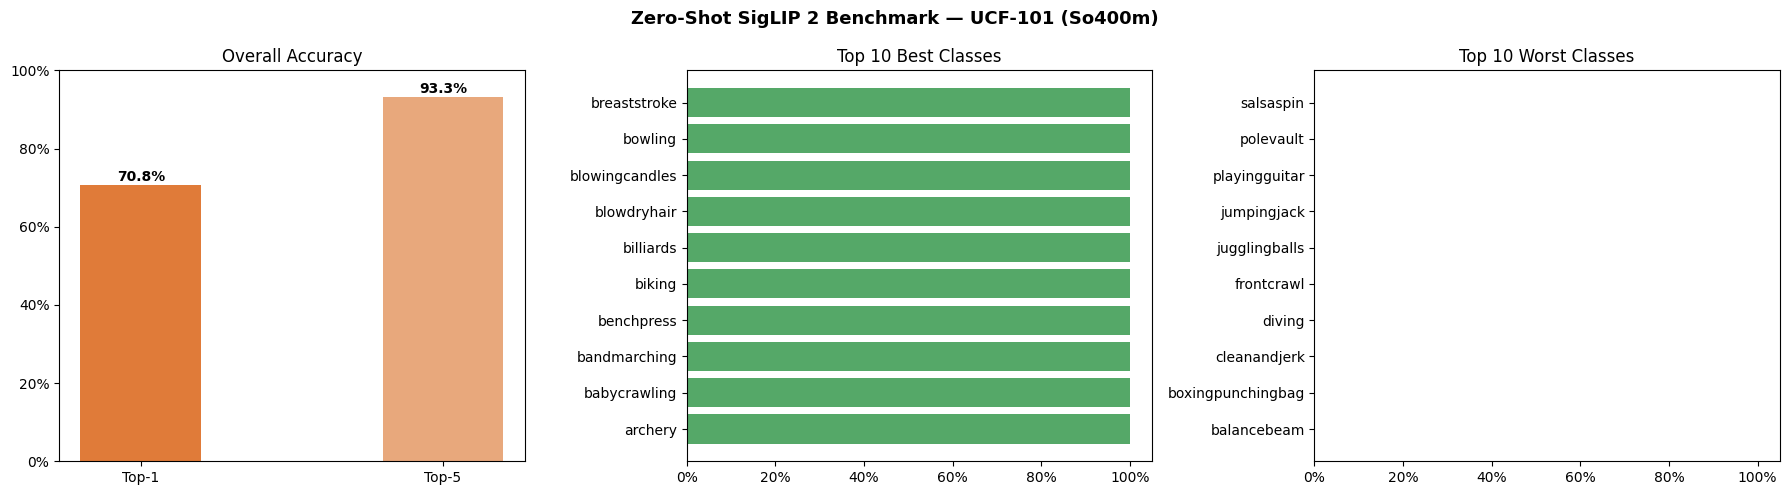

Plot saved to outputs/benchmark_siglip2.png


In [4]:
# Cell 4 — Metrics and plots
top1 = df['top1_correct'].mean() * 100
top5 = df['top5_correct'].mean() * 100
per_class = df.groupby('true_label')['top1_correct'].mean() * 100

metrics = {
    'model': MODEL_ID,
    'num_frames': NUM_FRAMES,
    'top1_accuracy': round(top1, 2),
    'top5_accuracy': round(top5, 2),
    'total_videos': len(df),
    'best_classes': per_class.nlargest(10).round(1).to_dict(),
    'worst_classes': per_class.nsmallest(10).round(1).to_dict(),
}
with open(f'{OUTPUT_DIR}/metrics_siglip2.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print(f'Top-1 Accuracy : {top1:.2f}%')
print(f'Top-5 Accuracy : {top5:.2f}%')
print(f'Total Videos   : {len(df)}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Zero-Shot SigLIP 2 Benchmark — UCF-101 (So400m)', fontsize=13, fontweight='bold')

axes[0].bar(['Top-1', 'Top-5'], [top1, top5], color=['#e07b39', '#e8a87c'], width=0.4)
axes[0].set_ylim(0, 100)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].set_title('Overall Accuracy')
for i, v in enumerate([top1, top5]):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

best10 = per_class.nlargest(10).sort_values()
axes[1].barh(best10.index, best10.values, color='#55A868')
axes[1].set_xlim(0, 105)
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set_title('Top 10 Best Classes')

worst10 = per_class.nsmallest(10).sort_values(ascending=False)
axes[2].barh(worst10.index, worst10.values, color='#C44E52')
axes[2].set_xlim(0, 105)
axes[2].xaxis.set_major_formatter(mtick.PercentFormatter())
axes[2].set_title('Top 10 Worst Classes')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/benchmark_siglip2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to outputs/benchmark_siglip2.png')